In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("logs/results.csv")
df.head()

,train_loss,test_loss,train_accuracy,test_accuracy,timestamp,checkpoint_dir_name,done,training_iteration,trial_id,date,...,hostname,node_ip,time_since_restore,iterations_since_restore,config/num_layers,config/num_filters,config/num_hidden_units,config/batch_size,config/learning_rate,logdir
0,0.321396,0.455594,0.900515,0.866434,1773571168,NaN,False,7,14dbe_00000,2026-03-15_11-39-28,...,MacBook-Pro-van-Steven.local,127.0.0.1,1781.168050,7,4,128,64,32,0.001,14dbe_00000
1,0.155378,0.362958,0.953015,0.904771,1773570042,NaN,False,6,14dbe_00001,2026-03-15_11-20-42,...,MacBook-Pro-van-Steven.local,127.0.0.1,654.230146,6,3,64,256,32,0.001,14dbe_00001
2,0.154129,0.367716,0.952087,0.907268,1773570029,NaN,False,7,14dbe_00002,2026-03-15_11-20-29,...,MacBook-Pro-van-Steven.local,127.0.0.1,642.096576,7,3,32,256,32,0.001,14dbe_00002
3,0.178181,0.346442,0.945070,0.904886,1773569925,NaN,False,6,14dbe_00003,2026-03-15_11-18-45,...,MacBook-Pro-van-Steven.local,127.0.0.1,537.906282,6,3,32,256,32,0.001,14dbe_00003
4,0.175975,0.439600,0.946899,0.891326,1773569891,NaN,False,6,14dbe_00004,2026-03-15_11-18-11,...,MacBook-Pro-van-Steven.local,127.0.0.1,503.254293,6,2,32,256,32,0.001,14dbe_00004


In [2]:
def plot_heatmap(df, index, columns, values="test_accuracy", ax=None):
    """Plot a heatmap of two hyperparameters against a metric."""
    pivot = df.pivot_table(
        values=values,
        index=index,
        columns=columns,
        aggfunc="max",
    )
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlOrRd", ax=ax)
    ax.set_title(f"{index.split('/')[-1]} vs {columns.split('/')[-1]}")

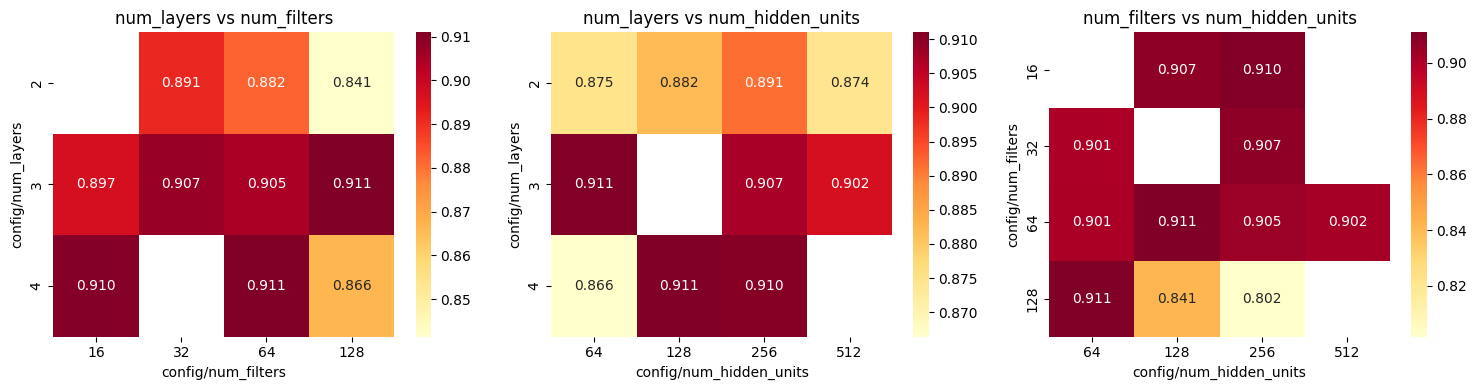

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

plot_heatmap(df, "config/num_layers", "config/num_filters", ax=axes[0])
plot_heatmap(df, "config/num_layers", "config/num_hidden_units", ax=axes[1])
plot_heatmap(df, "config/num_filters", "config/num_hidden_units", ax=axes[2])

plt.tight_layout()
plt.show()

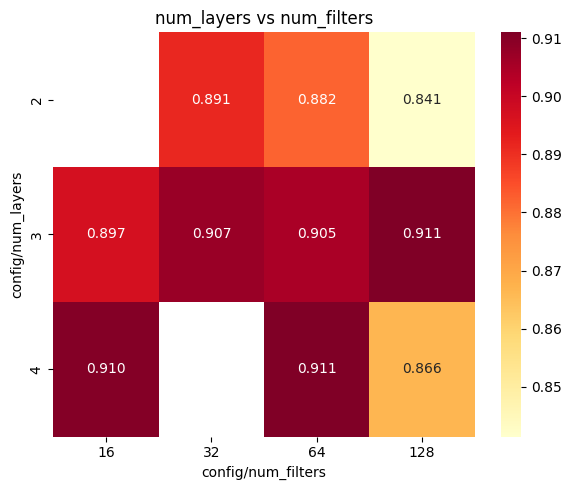

In [15]:
import matplotlib.pyplot as plt

# Create a single figure and axis (adjust figsize as needed)
fig, ax = plt.subplots(figsize=(6, 5))

# Call your plotting function, passing the single axis
plot_heatmap(df, "config/num_layers", "config/num_filters", ax=ax)

plt.tight_layout()
plt.show()

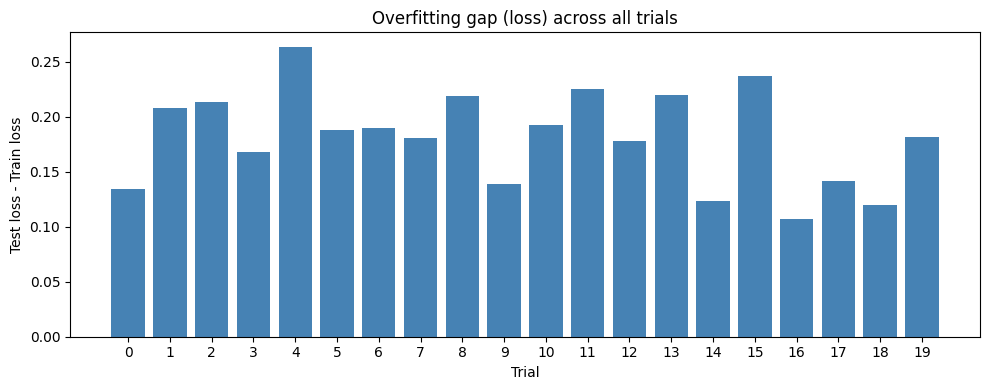

In [7]:
df["loss_gap"] = df["test_loss"] - df["train_loss"]

plt.figure(figsize=(10, 4))
plt.bar(range(len(df)), df["loss_gap"], color="steelblue")
plt.xticks(range(len(df)), range(len(df)))
plt.xlabel("Trial")
plt.ylabel("Test loss - Train loss")
plt.title("Overfitting gap (loss) across all trials")
plt.tight_layout()
plt.show()

In [8]:
print(df.iloc[16][["config/num_layers", "config/num_filters", "config/num_hidden_units", "loss_gap", "test_accuracy"]])

config/num_layers                 4
config/num_filters               16
config/num_hidden_units         256
loss_gap                   0.107386
test_accuracy              0.910418
Name: 16, dtype: object


In [9]:
print(df.iloc[4][["config/num_layers", "config/num_filters", "config/num_hidden_units", "loss_gap", "test_accuracy"]])

config/num_layers                 2
config/num_filters               32
config/num_hidden_units         256
loss_gap                   0.263626
test_accuracy              0.891326
Name: 4, dtype: object


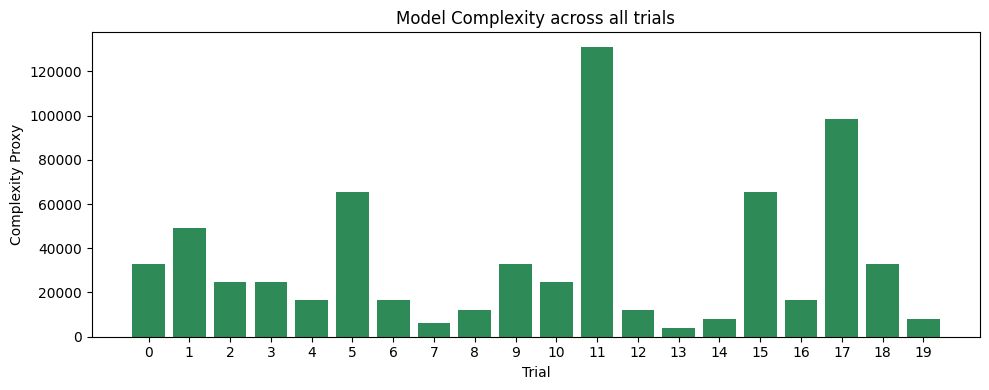

In [10]:
df["complexity"] = df["config/num_layers"] * df["config/num_filters"] * df["config/num_hidden_units"]

plt.figure(figsize=(10, 4))
plt.bar(range(len(df)), df["complexity"], color="seagreen")
plt.xticks(range(len(df)), range(len(df)))
plt.xlabel("Trial")
plt.ylabel("Complexity Proxy")
plt.title("Model Complexity across all trials")
plt.tight_layout()
plt.show()

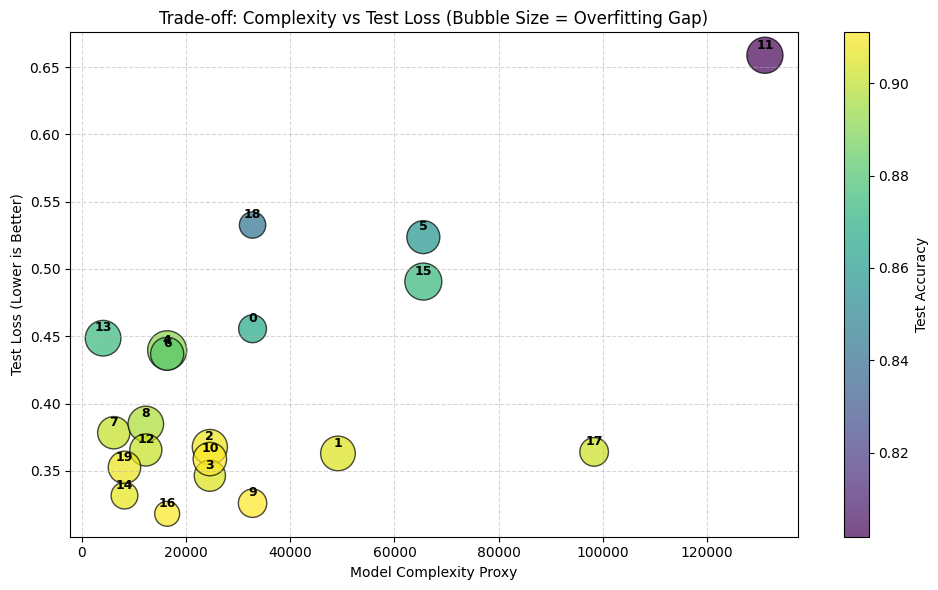

In [11]:
plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    x=df["complexity"], 
    y=df["test_loss"], 
    s=df["loss_gap"] * 3000,  # Scale up the gap so bubbles are visible
    c=df["test_accuracy"], 
    cmap="viridis", 
    alpha=0.7, 
    edgecolors="black"
)

# Add Trial IDs to each bubble
for i in range(len(df)):
    plt.text(df["complexity"][i], df["test_loss"][i] + 0.005, str(i), 
             fontsize=9, ha='center', fontweight='bold')

plt.colorbar(scatter, label="Test Accuracy")
plt.xlabel("Model Complexity Proxy")
plt.ylabel("Test Loss (Lower is Better)")
plt.title("Trade-off: Complexity vs Test Loss (Bubble Size = Overfitting Gap)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [17]:
df2 = pd.read_csv("logs/results_2.csv")

# compare batchnorm True vs False
print(df2.groupby("config/batch_norm")["test_accuracy"].agg(["mean", "max", "min"]))

# best trial
best = df2.loc[df2["test_loss"].idxmin()]
print(f"\nBest trial:")
print(f"batch_norm: {best['config/batch_norm']}")
print(f"dropout: {best['config/drop_out']:.3f}")
print(f"test_accuracy: {best['test_accuracy']:.4f}")
print(f"loss_gap: {best['test_loss'] - best['train_loss']:.4f}")

                       mean       max       min
config/batch_norm                              
False              0.908781  0.912953  0.905117
True               0.919366  0.924401  0.911955

Best trial:
batch_norm: True
dropout: 0.074
test_accuracy: 0.9190
loss_gap: 0.0793


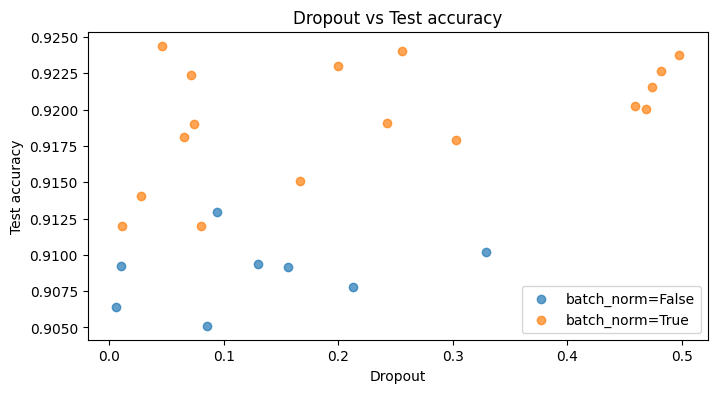

In [18]:
plt.figure(figsize=(8, 4))
for bn, group in df2.groupby("config/batch_norm"):
    plt.scatter(group["config/drop_out"], group["test_accuracy"], 
                label=f"batch_norm={bn}", alpha=0.7)
plt.xlabel("Dropout")
plt.ylabel("Test accuracy")
plt.legend()
plt.title("Dropout vs Test accuracy")
plt.show()

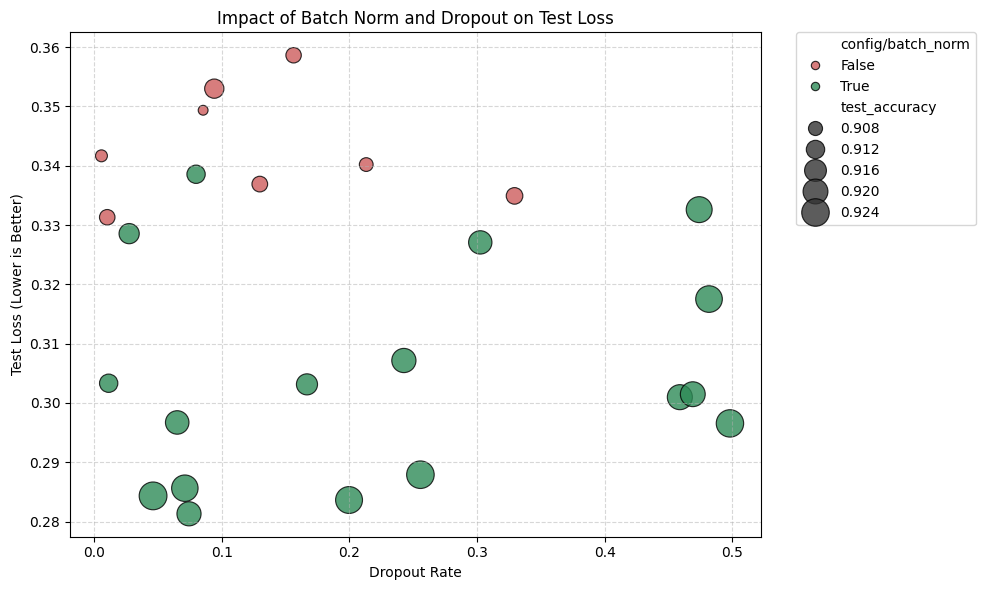

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the gap is calculated just in case you want to swap the bubble size
df2["loss_gap"] = df2["test_loss"] - df2["train_loss"]

plt.figure(figsize=(10, 6))

# Create the scatter plot
sns.scatterplot(
    data=df2,
    x="config/drop_out",
    y="test_loss",
    hue="config/batch_norm",
    size="test_accuracy",        # Larger bubbles = better accuracy
    sizes=(50, 400),             # Control the min/max bubble size
    palette={True: "seagreen", False: "indianred"}, # Distinct colors
    alpha=0.8,
    edgecolor="black"
)

plt.title("Impact of Batch Norm and Dropout on Test Loss")
plt.xlabel("Dropout Rate")
plt.ylabel("Test Loss (Lower is Better)")

# Move legend outside the plot area
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

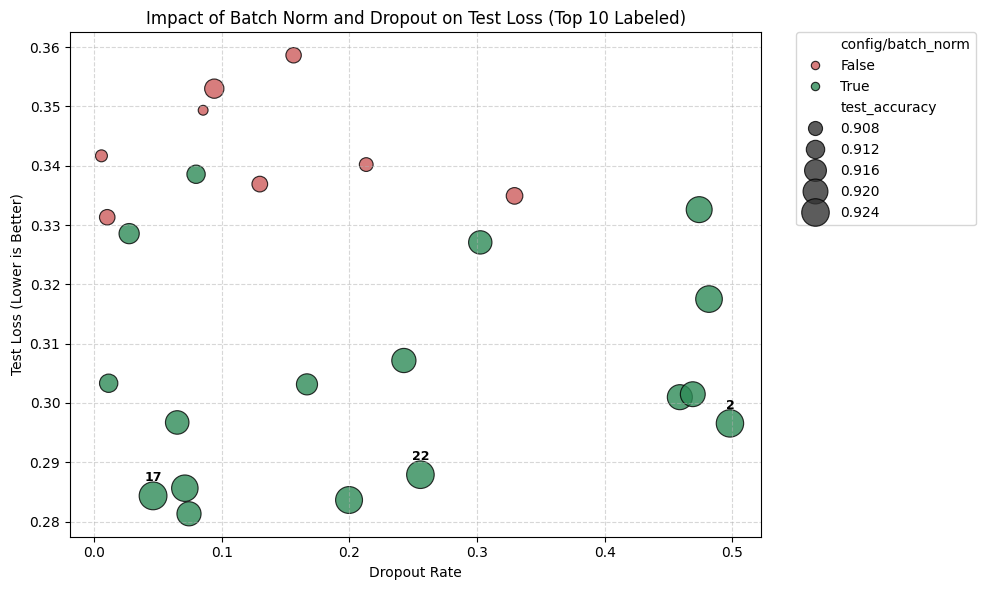

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# 1. Create the base scatter plot
sns.scatterplot(
    data=df2, # (Make sure this is your Phase B dataframe!)
    x="config/drop_out",
    y="test_loss",
    hue="config/batch_norm",
    size="test_accuracy",        
    sizes=(50, 400),             
    palette={True: "seagreen", False: "indianred"}, 
    alpha=0.8,
    edgecolor="black"
)

# 2. Extract the top 3 trials by accuracy
top_10_indices = df2.nlargest(3, "test_accuracy").index

# 3. Add text labels ONLY for those top 10 trials
for i in top_10_indices:
    x_val = df2.loc[i, "config/drop_out"]
    y_val = df2.loc[i, "test_loss"]
    
    # Offset the text slightly on the Y-axis so it sits just above the bubble
    plt.text(x_val, y_val + 0.002, str(i), 
             fontsize=9, ha='center', va='bottom', fontweight='bold')

plt.title("Impact of Batch Norm and Dropout on Test Loss (Top 10 Labeled)")
plt.xlabel("Dropout Rate")
plt.ylabel("Test Loss (Lower is Better)")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [24]:
df3 = pd.read_csv("logs/results_3.csv")

print("Experiment 2 (random search):")
print(f"Best test accuracy: {df2['test_accuracy'].max():.4f}")
print(f"Best test loss: {df2['test_loss'].min():.4f}")
print(f"Mean test accuracy: {df2['test_accuracy'].mean():.4f}")

print("\nExperiment 3 (Optuna/Bayesian):")
print(f"Best test accuracy: {df3['test_accuracy'].max():.4f}")
print(f"Best test loss: {df3['test_loss'].min():.4f}")
print(f"Mean test accuracy: {df3['test_accuracy'].mean():.4f}")

Experiment 2 (random search):
Best test accuracy: 0.9244
Best test loss: 0.2813
Mean test accuracy: 0.9160

Experiment 3 (Optuna/Bayesian):
Best test accuracy: 0.9274
Best test loss: 0.2834
Mean test accuracy: 0.9143


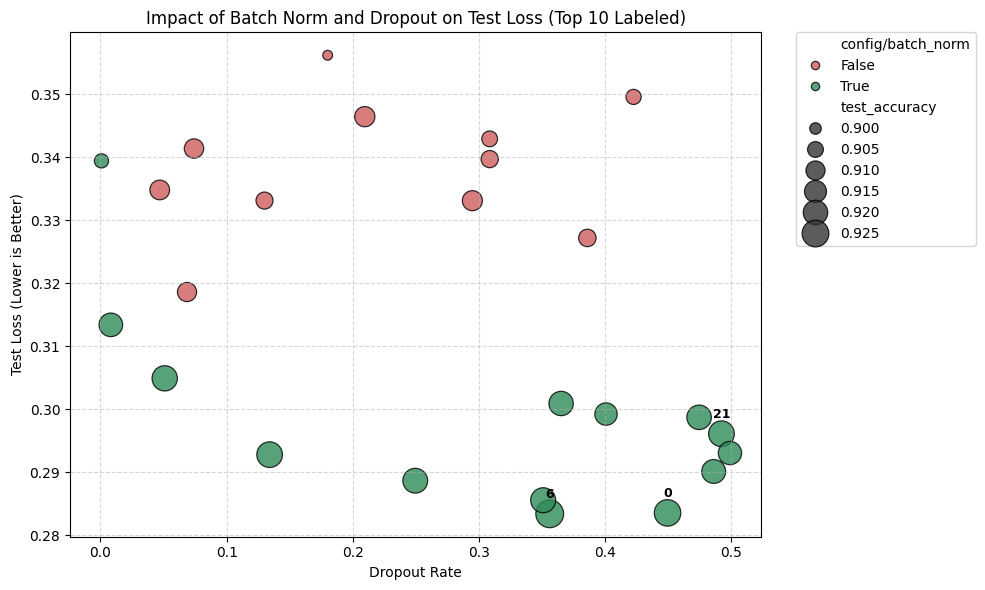

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# 1. Create the base scatter plot
sns.scatterplot(
    data=df3, # (Make sure this is your Phase B dataframe!)
    x="config/drop_out",
    y="test_loss",
    hue="config/batch_norm",
    size="test_accuracy",        
    sizes=(50, 400),             
    palette={True: "seagreen", False: "indianred"}, 
    alpha=0.8,
    edgecolor="black"
)

# 2. Extract the top 3 trials by accuracy
top_10_indices = df3.nlargest(3, "test_accuracy").index

# 3. Add text labels ONLY for those top 10 trials
for i in top_10_indices:
    x_val = df3.loc[i, "config/drop_out"]
    y_val = df3.loc[i, "test_loss"]
    
    # Offset the text slightly on the Y-axis so it sits just above the bubble
    plt.text(x_val, y_val + 0.002, str(i), 
             fontsize=9, ha='center', va='bottom', fontweight='bold')

plt.title("Impact of Batch Norm and Dropout on Test Loss (Top 10 Labeled)")
plt.xlabel("Dropout Rate")
plt.ylabel("Test Loss (Lower is Better)")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()